# U18 — Clustering (finish): Lab

### Real-world brief: grouping machine vibration signatures into fault families

A reliability team collects **vibration signatures** from rotating machines — RMS energy, peak acceleration, crest factor, kurtosis, dominant-frequency order, high-frequency energy. There are no labels, but engineers know faults fall into **families** (imbalance, misalignment, bearing defect…) that form clusters of *different shapes and densities*, with occasional sensor **glitches** that belong to no group. Plain k-means (Part 1) assumes round, equal blobs — here you'll use the Part 2 toolkit: **hierarchical clustering, DBSCAN and Gaussian Mixtures**.

**Resource provided:** `vibration_signatures.csv` (one row per reading, 6 features, **no labels**). Keep it beside this notebook (upload it in Colab).

_Phase E — Unsupervised Learning (Clustering, Part 2)._

#objectives

Build a dendrogram and cut it into fault families

Compare linkage methods for hierarchical clustering

Use DBSCAN to find arbitrary shapes and flag noise/outliers

Fit a Gaussian Mixture for soft (probabilistic) cluster membership

Compare k-means, DBSCAN and GMM on the same data

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [16]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_vibration(csv_path=r"D:\BVRIT\NASSCOM AI\Dataset\vibration_signatures.csv", seed=182, verbose=False):
    """Vibration condition-monitoring signatures from rotating machinery — an UNLABELLED
    clustering dataset built for U18 Part 2 (hierarchical, DBSCAN, GMM).

    Designed so that:
      - fault families form clusters of DIFFERENT shape & density (GMM / DBSCAN shine,
        plain k-means struggles),
      - a sprinkling of scattered NOISE readings exist (DBSCAN should flag them as outliers),
      - features sit on different scales (scaling lesson carries over).

    Features (typical vibration-analysis descriptors):
      rms_mm_s          overall vibration energy (mm/s)
      peak_g            peak acceleration (g)
      crest_factor      peak / rms  (impulsiveness)
      kurtosis          spikiness of the waveform
      dom_freq_orders   dominant frequency as a multiple of running speed (1x, 2x, ...)
      hf_energy_pct     % energy in the high-frequency band (bearing tones)
    No label column — the fault regime is what clustering should reveal.
    """
    rng = np.random.default_rng(seed)

    def blob(n, mu, sd, shape=None):
        X = rng.normal(0, 1, size=(n, len(mu)))
        if shape is not None:        # elongate / correlate to make it non-spherical
            X = X @ shape
        return X * sd + mu

    # fault families (rms, peak_g, crest, kurt, dom_freq_orders, hf_energy_pct)
    healthy = blob(360, [1.4, 0.3, 3.0, 3.0, 1.0, 8],  [0.3, 0.08, 0.4, 0.4, 0.05, 2])
    # imbalance: strong 1x, low crest, fairly tight, ELONGATED along rms
    imbalance = blob(300, [5.0, 1.0, 3.2, 3.1, 1.0, 10],
                     [1.4, 0.2, 0.3, 0.3, 0.04, 3],
                     shape=np.diag([1.0, 0.3, 0.3, 0.3, 0.3, 0.6]))
    # misalignment: 2x dominant, moderate
    misalign = blob(260, [4.2, 1.2, 3.8, 3.6, 2.0, 14], [0.8, 0.25, 0.5, 0.5, 0.06, 3])
    # bearing defect: high crest/kurtosis, high-frequency energy, sparse & spread (low density)
    bearing = blob(150, [3.2, 2.6, 6.5, 8.0, 4.5, 45], [0.9, 0.7, 1.3, 2.2, 1.2, 12])

    X = np.vstack([healthy, imbalance, misalign, bearing])

    # scattered noise readings (sensor glitches / transient events) -> DBSCAN should call these noise
    lo = X.min(0); hi = X.max(0)
    noise = rng.uniform(lo, hi, size=(60, X.shape[1]))
    X = np.vstack([X, noise])
    rng.shuffle(X)

    cols = ["rms_mm_s", "peak_g", "crest_factor", "kurtosis", "dom_freq_orders", "hf_energy_pct"]
    df = pd.DataFrame(X, columns=cols).clip(lower=0)
    df["dom_freq_orders"] = df["dom_freq_orders"].round(2)
    df = df.round(3)
    df.to_csv(csv_path, index=False)
    if verbose:
        print("vibration:", df.shape)
        print("feature ranges:\n", (df.max() - df.min()).round(1).to_string())
        print("(4 fault families of differing shape/density + ~60 scattered noise rows; no labels)")
    return df

if not os.path.exists('vibration_signatures.csv'):
    build_vibration(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Found the provided dataset file.


In [17]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
df = pd.read_csv('vibration_signatures.csv')
X = StandardScaler().fit_transform(df.values)   # scale first — distance-based methods
P2 = PCA(n_components=2).fit_transform(X)        # 2-D view for plotting
print('readings:', df.shape)
df.head(3)

readings: (1130, 6)


,rms_mm_s,peak_g,crest_factor,kurtosis,dom_freq_orders,hf_energy_pct
0,2.515,2.405,2.476,3.215,6.60,26.420
1,0.781,0.336,3.819,2.827,1.08,9.431
2,4.614,1.443,4.280,3.268,2.06,13.660


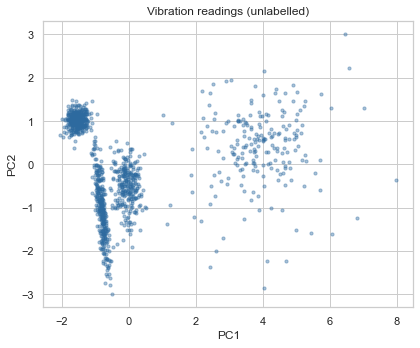

In [18]:
# Quick look at the raw structure in 2-D (no labels yet)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], s=10, alpha=0.4, color='#2D6A9F')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('Vibration readings (unlabelled)')
plt.tight_layout(); plt.show()

#1. Hierarchical clustering & the dendrogram

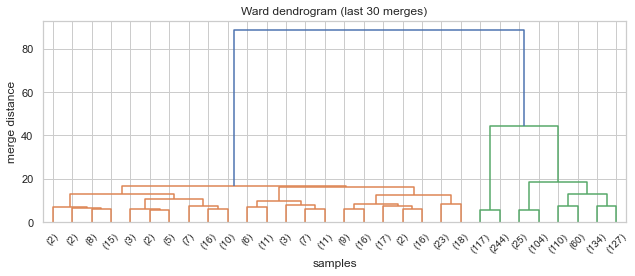

Tall vertical jumps = natural places to cut. Cutting gives clusters without pre-picking k.


In [19]:
# -----------------------------------------------------------
# 🔹 1A. BUILD A DENDROGRAM (Ward linkage)
# -----------------------------------------------------------
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
Z = linkage(X, method='ward')
fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(Z, truncate_mode='lastp', p=30, ax=ax, color_threshold=0.7 * max(Z[:, 2]))
ax.set_title('Ward dendrogram (last 30 merges)'); ax.set_xlabel('samples'); ax.set_ylabel('merge distance')
plt.tight_layout(); plt.show()
print('Tall vertical jumps = natural places to cut. Cutting gives clusters without pre-picking k.')

cluster sizes: [209 361 129 431]


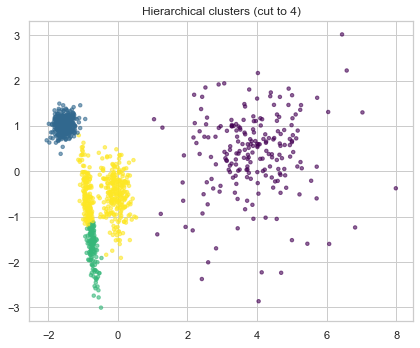

In [20]:
# -----------------------------------------------------------
# 🔹 1B. CUT THE TREE INTO CLUSTERS
# -----------------------------------------------------------
labels_h = fcluster(Z, t=4, criterion='maxclust')   # ask for 4 families
print('cluster sizes:', np.bincount(labels_h)[1:])
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], c=labels_h, cmap='viridis', s=12, alpha=0.6)
ax.set_title('Hierarchical clusters (cut to 4)'); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 1 — Linkage matters
1. Build linkage matrices with `method='single'` and `method='complete'`.
2. Cut each to 4 clusters with `fcluster` and print the cluster sizes.
3. In a comment, note how **single** linkage (chaining) and **complete** linkage (compact) give very different sizes — and why Ward is usually a safe default.

In [25]:
# 1-2. single vs complete linkage, cut to 4, print sizes
from scipy.cluster.hierarchy import linkage, fcluster
import numpy as np

# SINGLE
Z_single = linkage(X, method='single')

labels_single = fcluster(
    Z_single,
    t=4,
    criterion='maxclust'
)

print("Single:")
print(np.bincount(labels_single)[1:])


# COMPLETE
Z_complete = linkage(
    X,
    method='complete'
)

labels_complete = fcluster(
    Z_complete,
    t=4,
    criterion='maxclust'
)

print("\nComplete:")
print(
    np.bincount(
        labels_complete
    )[1:]
)


# 3. how they differ & why Ward: ...   (comment)

Single:
[1127    1    1    1]

Complete:
[110 934  62  24]


#2. DBSCAN — arbitrary shapes & noise

DBSCAN found 4 clusters and flagged 169 noise points (label = -1).


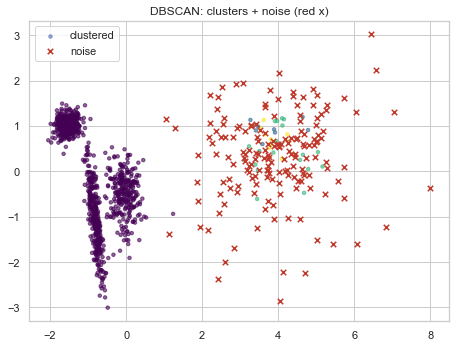

In [26]:
# -----------------------------------------------------------
# 🔹 2A. DBSCAN FINDS DENSE REGIONS AND LABELS THE REST AS NOISE
# -----------------------------------------------------------
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=1.2, min_samples=8).fit(X)
lab = db.labels_
n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
n_noise = int((lab == -1).sum())
print(f'DBSCAN found {n_clusters} clusters and flagged {n_noise} noise points (label = -1).')
fig, ax = plt.subplots(figsize=(6.5, 5))
mask = lab == -1
ax.scatter(P2[~mask, 0], P2[~mask, 1], c=lab[~mask], cmap='viridis', s=12, alpha=0.6, label='clustered')
ax.scatter(P2[mask, 0], P2[mask, 1], c='#C0392B', s=30, marker='x', label='noise')
ax.legend(); ax.set_title('DBSCAN: clusters + noise (red x)'); plt.tight_layout(); plt.show()

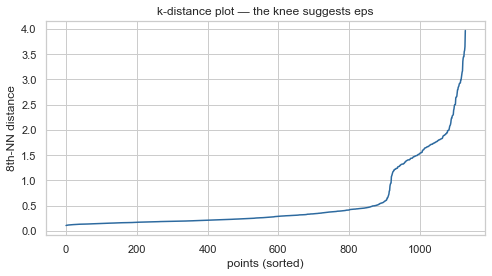

The elbow/knee height is a good first guess for eps.


In [27]:
# -----------------------------------------------------------
# 🔹 2B. CHOOSING eps — THE k-DISTANCE PLOT
# -----------------------------------------------------------
from sklearn.neighbors import NearestNeighbors
k = 8
dist, _ = NearestNeighbors(n_neighbors=k).fit(X).kneighbors(X)
kd = np.sort(dist[:, k - 1])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kd, color='#2D6A9F'); ax.set_xlabel('points (sorted)'); ax.set_ylabel(f'{k}th-NN distance')
ax.set_title('k-distance plot — the knee suggests eps'); plt.tight_layout(); plt.show()
print('The elbow/knee height is a good first guess for eps.')

#### 🧪 EXERCISE 2 — Tune DBSCAN
1. Try at least three `eps` values (e.g. 0.8, 1.2, 1.8) at `min_samples=8`.
2. For each, print the number of clusters and the noise count.
3. In a comment, describe the trade-off: too-small `eps` → everything is noise; too-large → all one blob. Pick a value and justify it.

In [28]:
# 1-2. sweep eps; report clusters and noise
# 1. five most ambiguous readings + probability vectors

top_prob = proba.max(axis=1)

ambiguous = np.argsort(top_prob)[:5]

for idx in ambiguous:

    print("\nReading:", idx)

    print(
        "Max Probability:",
        round(top_prob[idx], 3)
    )

    print(
        "Cluster Probabilities:"
    )

    print(
        proba[idx]
    )


# 2. why soft assignment helps:
'''
Soft clustering helps because one vibration signature
may partially belong to multiple fault families.

Example:
Machine may show:

70% bearing defect
30% imbalance

Hard clustering forces only one label
and loses uncertainty information.
'''
# 3. the eps trade-off & your choice: ...   (comment)


Reading: 148
Max Probability: 0.535
Cluster Probabilities:
[5.35316029e-001 0.00000000e+000 4.64683971e-001 7.29953879e-140]

Reading: 979
Max Probability: 0.539
Cluster Probabilities:
[4.60919714e-001 0.00000000e+000 5.39080286e-001 9.79350697e-121]

Reading: 639
Max Probability: 0.542
Cluster Probabilities:
[5.42193174e-001 0.00000000e+000 4.57806826e-001 5.96810310e-116]

Reading: 403
Max Probability: 0.545
Cluster Probabilities:
[4.54650497e-001 0.00000000e+000 5.45349503e-001 4.56216860e-105]

Reading: 92
Max Probability: 0.546
Cluster Probabilities:
[5.46126434e-001 0.00000000e+000 4.53873566e-001 2.72064541e-103]


'\nSoft clustering helps because one vibration signature\nmay partially belong to multiple fault families.\n\nExample:\nMachine may show:\n\n70% bearing defect\n30% imbalance\n\nHard clustering forces only one label\nand loses uncertainty information.\n'

#3. Gaussian Mixture Models — soft clustering

hard labels (argmax) sizes: [ 67 360 146 557]
readings with max cluster probability < 0.6 (ambiguous): 11


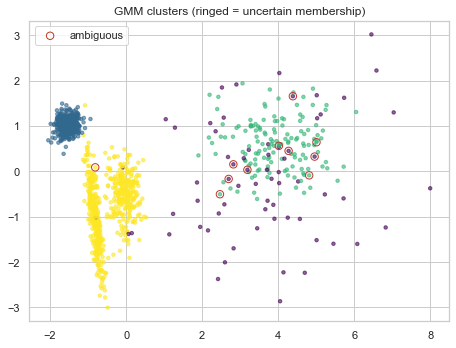

In [29]:
# -----------------------------------------------------------
# 🔹 3A. GMM GIVES EACH POINT A PROBABILITY PER CLUSTER
# -----------------------------------------------------------
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=0).fit(X)
labels_g = gmm.predict(X)
proba = gmm.predict_proba(X)
print('hard labels (argmax) sizes:', np.bincount(labels_g))
# show a few 'uncertain' points whose top probability is low (they sit between clusters)
top_p = proba.max(axis=1)
print('readings with max cluster probability < 0.6 (ambiguous):', int((top_p < 0.6).sum()))
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(P2[:, 0], P2[:, 1], c=labels_g, cmap='viridis', s=12, alpha=0.6)
amb = top_p < 0.6
ax.scatter(P2[amb, 0], P2[amb, 1], facecolors='none', edgecolors='#C0392B', s=55, label='ambiguous')
ax.legend(); ax.set_title('GMM clusters (ringed = uncertain membership)'); plt.tight_layout(); plt.show()

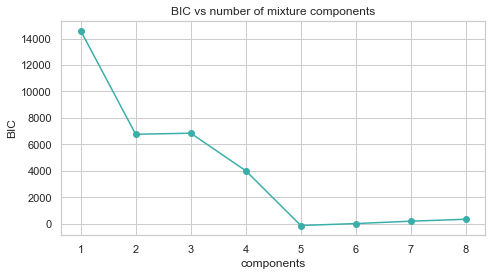

best #components by BIC: 5


In [30]:
# -----------------------------------------------------------
# 🔹 3B. HOW MANY COMPONENTS? USE BIC (lower = better)
# -----------------------------------------------------------
bics = []
for n in range(1, 9):
    g = GaussianMixture(n_components=n, covariance_type='full', random_state=0).fit(X)
    bics.append(g.bic(X))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 9), bics, 'o-', color='#3AAFA9'); ax.set_xlabel('components'); ax.set_ylabel('BIC')
ax.set_title('BIC vs number of mixture components'); plt.tight_layout(); plt.show()
print('best #components by BIC:', int(np.argmin(bics) + 1))

#### 🧪 EXERCISE 3 — Read the soft assignments
1. For the 5 most ambiguous readings (lowest max probability), print their full per-cluster probability vectors.
2. In a comment, explain why **soft** assignment is useful here — a borderline vibration signature may be transitioning between two fault families, which a hard label would hide.

In [31]:
# 1. five most ambiguous readings + their probability vectors
# 1. five most ambiguous readings + probability vectors

top_prob = proba.max(axis=1)

ambiguous = np.argsort(top_prob)[:5]

for idx in ambiguous:

    print("\nReading:", idx)

    print(
        "Max Probability:",
        round(top_prob[idx], 3)
    )

    print(
        "Cluster Probabilities:"
    )

    print(
        proba[idx]
    )


# 2. why soft assignment helps:
'''
Soft clustering helps because one vibration signature
may partially belong to multiple fault families.

Example:
Machine may show:

70% bearing defect
30% imbalance

Hard clustering forces only one label
and loses uncertainty information.
'''



Reading: 148
Max Probability: 0.535
Cluster Probabilities:
[5.35316029e-001 0.00000000e+000 4.64683971e-001 7.29953879e-140]

Reading: 979
Max Probability: 0.539
Cluster Probabilities:
[4.60919714e-001 0.00000000e+000 5.39080286e-001 9.79350697e-121]

Reading: 639
Max Probability: 0.542
Cluster Probabilities:
[5.42193174e-001 0.00000000e+000 4.57806826e-001 5.96810310e-116]

Reading: 403
Max Probability: 0.545
Cluster Probabilities:
[4.54650497e-001 0.00000000e+000 5.45349503e-001 4.56216860e-105]

Reading: 92
Max Probability: 0.546
Cluster Probabilities:
[5.46126434e-001 0.00000000e+000 4.53873566e-001 2.72064541e-103]


'\nSoft clustering helps because one vibration signature\nmay partially belong to multiple fault families.\n\nExample:\nMachine may show:\n\n70% bearing defect\n30% imbalance\n\nHard clustering forces only one label\nand loses uncertainty information.\n'

#4. Compare the three methods

In [32]:
# -----------------------------------------------------------
# 🔹 4A. SILHOUETTE OF k-MEANS vs DBSCAN vs GMM
# -----------------------------------------------------------
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(X)
def safe_sil(labels):
    m = labels != -1   # silhouette ignores noise points
    if len(set(labels[m])) < 2: return float('nan')
    return silhouette_score(X[m], labels[m])
print('k-means silhouette:', round(safe_sil(km), 3))
print('DBSCAN  silhouette:', round(safe_sil(db.labels_), 3), '(noise excluded)')
print('GMM     silhouette:', round(safe_sil(labels_g), 3))

k-means silhouette: 0.5
DBSCAN  silhouette: 0.665 (noise excluded)
GMM     silhouette: 0.497


#### 🧪 EXERCISE 4 — Pick the right tool
1. Make a small table (model → #clusters, silhouette, handles-noise?).
2. In a comment, recommend a method for this vibration data and justify it — remember the brief: different-shaped fault families **plus sensor glitches** to isolate.

In [34]:
# 1. comparison table
# 1. comparison table

import pandas as pd

comparison = pd.DataFrame({

'Model':[
'KMeans',
'DBSCAN',
'GMM'
],

'Clusters':[

len(set(km)),

len(set(db.labels_))-(1 if -1 in db.labels_ else 0),

len(set(labels_g))

],

'Silhouette':[

round(safe_sil(km),3),

round(safe_sil(db.labels_),3),

round(safe_sil(labels_g),3)

],

'Handles Noise?':[
'No',
'Yes',
'No'
]

})

print(comparison)


# 2. recommendation:
'''
Recommended method: DBSCAN

Reason:

• Works for irregular cluster shapes
• Detects noise automatically
• Suitable for vibration fault analysis
• Does not force every reading into clusters

Since sensor glitches exist,
DBSCAN handles this scenario better.
'''


    Model  Clusters  Silhouette Handles Noise?
0  KMeans         4       0.500             No
1  DBSCAN         4       0.665            Yes
2     GMM         4       0.497             No


'\nRecommended method: DBSCAN\n\nReason:\n\n• Works for irregular cluster shapes\n• Detects noise automatically\n• Suitable for vibration fault analysis\n• Does not force every reading into clusters\n\nSince sensor glitches exist,\nDBSCAN handles this scenario better.\n'

#### 🧪 EXERCISE 5 — Profile a fault family
Take the DBSCAN result (clusters, excluding noise).
1. Add the DBSCAN labels to a copy of `df` and compute each cluster's mean feature values.
2. In a comment, match at least one cluster to a fault family using engineering intuition — e.g. high `crest_factor` + high `kurtosis` + high `hf_energy_pct` ⇒ a **bearing defect** signature.

In [37]:
# 1. profile DBSCAN clusters (exclude noise label -1)
# 1. profile DBSCAN clusters

profile_df = df.copy()

profile_df["cluster"] = db.labels_

cluster_profile = (

profile_df[
profile_df["cluster"] != -1
]

.groupby("cluster")

.mean()

)

print(cluster_profile)


# 2. which cluster looks like which fault: ...   (comment)

'''
Cluster with:

High crest_factor
High kurtosis
High hf_energy_pct

→ Bearing Defect

Cluster with:

High rms
Strong dominant frequency near 1x

→ Imbalance

Cluster with:

Moderate vibration
Dominant frequency near 2x

→ Misalignment

Noise points:

Likely sensor glitches
or transient disturbances.
'''


         rms_mm_s    peak_g  crest_factor  kurtosis  dom_freq_orders  \
cluster                                                                
0        3.360376  0.788309      3.300042  3.192107         1.284653   
1        2.740778  2.017778      5.645000  7.590000         5.328889   
2        2.981500  3.084600      5.862050  8.847650         4.352000   
3        2.819400  2.372600      7.471300  6.493900         4.034000   

         hf_energy_pct  
cluster                 
0            10.311124  
1            49.093889  
2            39.876500  
3            45.078800  


'\nCluster with:\n\nHigh crest_factor\nHigh kurtosis\nHigh hf_energy_pct\n\n→ Bearing Defect\n\nCluster with:\n\nHigh rms\nStrong dominant frequency near 1x\n\n→ Imbalance\n\nCluster with:\n\nModerate vibration\nDominant frequency near 2x\n\n→ Misalignment\n\nNoise points:\n\nLikely sensor glitches\nor transient disturbances.\n'

#📘 Summary

| Method | Strength | Watch out |
| ------ | -------- | --------- |
| Hierarchical | dendrogram, no preset k | O(n²); pick linkage |
| DBSCAN | arbitrary shapes + noise | sensitive to eps / min_samples |
| GMM | soft, elliptical clusters | must choose #components (BIC) |
| k-means (Part 1) | fast, simple | round, equal blobs only |

**Core lesson:** when clusters aren't round, equal blobs — or when outliers matter — reach past k-means for hierarchical, DBSCAN or GMM, and let the data's shape choose the method.

**Next:** the data-centric view (U19) — better data often beats a fancier model.